# AirBnB NYC Analytics Project 

* Project by Nhi Bui · Villanova University · [GitHub](https://github.com/nhibui23/airbnb-saas-product-analytics) · [LinkedIn](https://linkedin.com/in/nhiuyenbui)

## 07. Follow-up: Validating the Queens Finding

The original Python location analysis identified the Bronx 
as Airbnb's growth opportunity with high ratings and low supply. But when I 
extended the analysis in SQL using **demand-per-listing**, a different leader emerged: **Queens**.

* Purpose: Therefore, this notebook will close the loop by returning to Python to visualize the SQL finding and refine the original recommendation. The SQL analysis returned a 100+ row table of every Queens neighborhood, which now will be brought to Python for clear confirmation. 

**Key Findings**
- Which specific Queens neighborhoods need host-acquisition investment
- Whether "Entire home/apt wins in Queens" finding holds visually
- A shortlist of 5-10 neighborhoods for the team

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv('../data/Airbnb_Open_Data_Cleaned.csv')
print(df.shape)

# Apply Airbnb branding guidelines
airbnb_coral = '#FF5A5F'  
airbnb_teal = '#00A699'   
airbnb_orange = '#FC642D' 
airbnb_dark = '#484848'   
airbnb_gray = '#767676'  

airbnb_palette = [airbnb_coral, airbnb_teal, airbnb_orange, airbnb_dark, airbnb_gray]

sns.set_palette(airbnb_palette)
sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

(63718, 21)


## Heatmap: Rating by Neighborhood vs Room Type

In [2]:
queens = df[df['neighbourhood group'] == 'Queens'].copy()

In [3]:
# Build the neighborhood vs room type matrix
heatmap_data = queens.groupby(['neighbourhood', 'room type']).agg(avg_rating=('review rate number', 'mean'), listings=('id', 'count')).reset_index()

In [4]:
# Filter to minimum 20 listings
heatmap_data = heatmap_data[heatmap_data['listings'] >= 20]


In [5]:
# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot(
    index='neighbourhood',
    columns='room type',
    values='avg_rating'
)


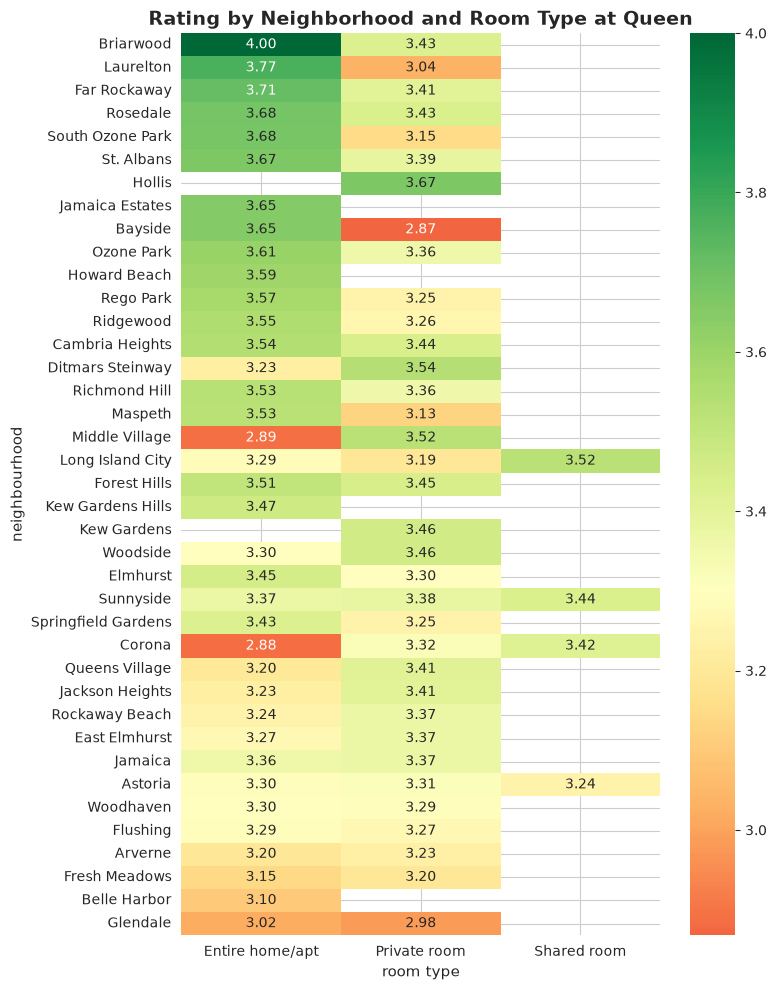

In [9]:
#Plot heatmap visualization

plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=3.3)
plt.title('Rating by Neighborhood and Room Type at Queen')
plt.tight_layout()
plt.show()

In [10]:
# Keep only top 20 by max rating per row
heatmap_pivot = heatmap_pivot.loc[
    heatmap_pivot.max(axis=1).sort_values(ascending=False).head(20).index
]

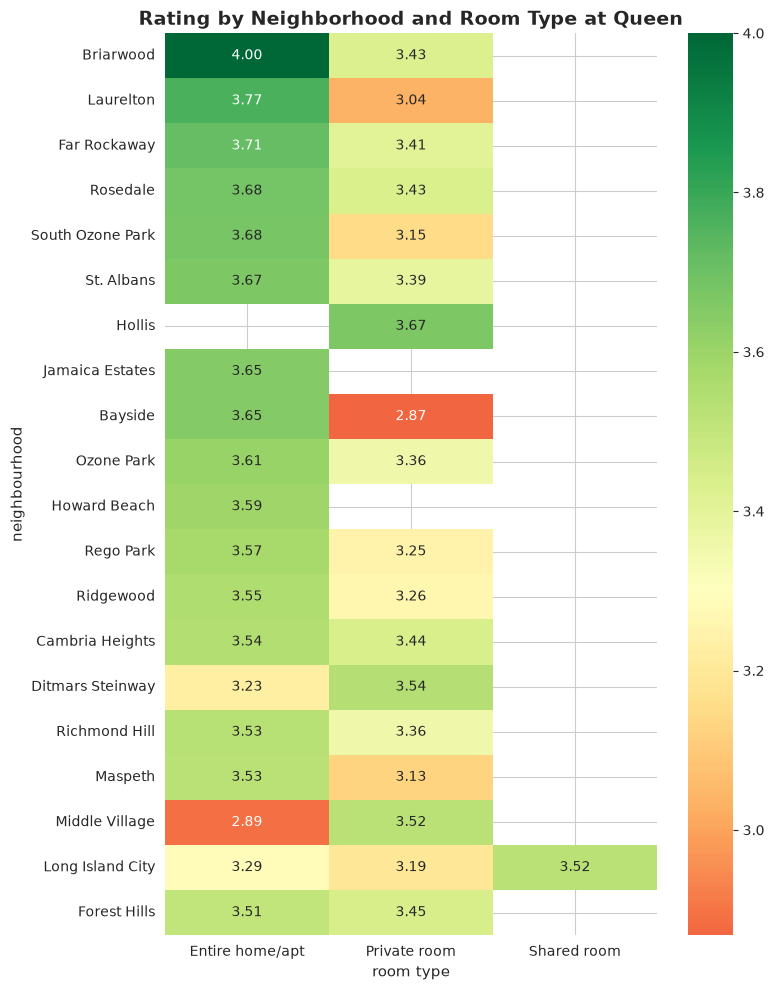

In [11]:
#Plot heatmap visualization again

plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=3.3)
plt.title('Rating by Neighborhood and Room Type at Queen')
plt.tight_layout()
plt.show()

### Key Takeaway

* Briarwood Entire home/apt leads Queens at 4 star, with Entire homes dominating 9 of the top 12 rankings
- Bayside shows the most dramatic contrast: Entire homes at 3.65 star vs Private rooms at 2.87 star 

### Interpretation

* Queens draws a different guest base than Manhattan or Brooklyn: families visiting relatives, business travelers near JFK, longer-stay professionals
* These guests reward listings that feel like real homes (kitchens, privacy, space) over budget room-rentals
* The room-type decision hosts make at signup quietly drives their long-term rating, search rank, and earnings
* Hosts listing Private rooms in markets like Bayside start at a disadvantage that most never recognize

### Recommendation

1. **Build a Room Type Recommender** 

* At onboarding, when a Queens host enters their address, surface the local data.

* For example: "In Bayside, Entire homes average 3.65★ vs 2.87★ for Private rooms. If your space allows, consider listing the entire unit."

2. **Add a Neighborhood Quality Tier badge** 

* Add badge to recognize consistently top-performing markets (Briarwood, Laurelton, Far Rockaway, Rosedale, St. Albans). Most new hosts default to Astoria or LIC, which misses higher-quality opportunities elsewhere in the borough

* Pilot the badge across these 5 neighborhoods and measure new-host acquisition over 6 months, and expand to Bronx target neighborhoods (Mott Haven, Schuylerville, Belmont) if results hold

## Supply Distribution Across Queens

The heatmap showed which neighborhoods rate highest. But to identify investment opportunities, we also need to see where listings are concentrated. Saturated markets like Astoria already have 1,000+ listings, so new hosts there compete with established supply. Lower-supply neighborhoods like Briarwood and Laurelton leave more room to enter.

This chart shows the listing count per Queens neighborhood (top 30 by supply).

In [18]:
# Count listings per neighborhood
supply = queens.groupby('neighbourhood').size().reset_index(name='listings')
supply = supply.sort_values('listings', ascending=False).head(30)

In [19]:
# Flip for horizontal bar
supply = supply.sort_values('listings', ascending=True)

In [20]:
# Highlight the top-rated investment targets in coral
target_neighborhoods = ['Briarwood', 'Laurelton', 'Far Rockaway', 'Bayside', 'Rosedale', 'St. Albans']
colors = [airbnb_coral if n in target_neighborhoods else airbnb_gray
          for n in supply['neighbourhood']]

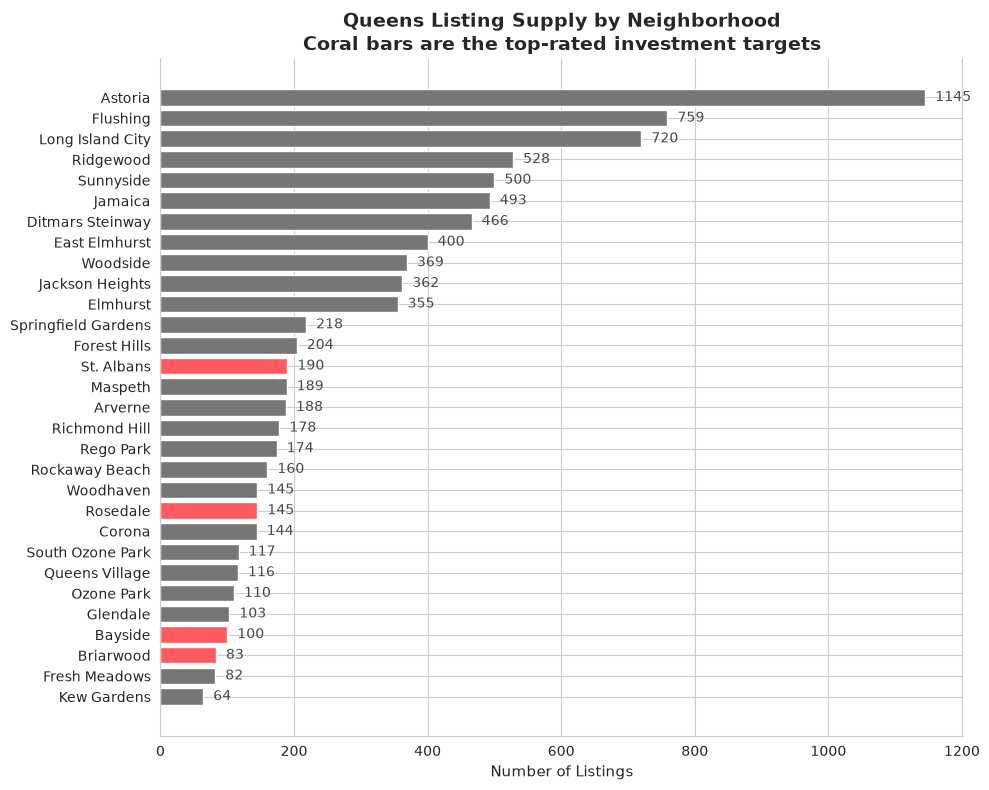

In [21]:
# Plot
plt.figure(figsize=(10, 8))
plt.barh(supply['neighbourhood'], supply['listings'], color=colors)

# Annotate each bar with listing count
for i, (name, count) in enumerate(zip(supply['neighbourhood'], supply['listings'])):
    plt.text(count + 15, i, str(count), va='center', fontsize=10, color=airbnb_dark)

plt.title('Queens Listing Supply by Neighborhood\nCoral bars are the top-rated investment targets')
plt.xlabel('Number of Listings')
plt.tight_layout()
plt.show()

### Key Takeaway

* Astoria dominates Queens supply with 1,145 listings, which is  more than 14x the size of top-rated Briarwood (83 listings)

* All 4 top-rated investment targets sit in the bottom third* of supply rankings — St. Albans (190), Rosedale (145), Bayside (100), Briarwood (83)

### Interpretation

* Most new Queens hosts default to whichever neighborhood they've heard of, which means Astoria, LIC, and Flushing keep growing while higher-quality markets stay small

* The over-supplied neighborhoods are just more discoverable to hosts, creating a concentration that hurts new-host outcomes

* A new host entering Astoria competes against 1,145 established listings on the same search results page, while a new host entering Briarwood competes against 83, which is an easier path

### Recommendation

1. **Add a "Considered Underserved" tag in host signup**

When a new host enters an over-supplied neighborhood like Astoria, surface a suggestion: *"Consider Briarwood instead? 83 listings, 4.0 star  avg rating, similar commute to Manhattan."*

2. **Track new-host first-90-day ratings** by neighborhood entry point

If hosts who are guided to lower-supply markets outperform Astoria entrants, the feature increases retention

3. **Combine with the Neighborhood Quality Tier badge**

The two features work together to identify hosts toward high-quality lower-competition markets